In [2]:
## loading the data after the data undergoes EDA
import pandas as pd

df = pd.read_csv("ai_ml_nlp_dataset.csv")
print(df.shape)
print(df.info())

(144053, 6)
<class 'pandas.DataFrame'>
RangeIndex: 144053 entries, 0 to 144052
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   id               144053 non-null  object
 1   abstract         144053 non-null  str   
 2   categories       144053 non-null  str   
 3   year             144053 non-null  int64 
 4   period           144053 non-null  str   
 5   abstract_length  144053 non-null  int64 
dtypes: int64(2), object(1), str(3)
memory usage: 6.6+ MB
None


C:\Users\pavit\AppData\Local\Temp\ipykernel_16876\2615577293.py:4: DtypeWarning: Columns (0: id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ai_ml_nlp_dataset.csv")


Text Preprocessing

In [14]:
## checking the abstract to know wat are the content it conatin 
#print(df['abstract'].iloc[14])
#print(df['abstract'].iloc[0])
print(df['abstract'].iloc[35525])

  Deep learning as a means to inferencing has proliferated thanks to its
versatility and ability to approach or exceed human-level accuracy. These
computational models have seemingly insatiable appetites for computational
resources not only while training, but also when deployed at scales ranging
from data centers all the way down to embedded devices. As such, increasing
consideration is being made to maximize the computational efficiency given
limited hardware and energy resources and, as a result, inferencing with
reduced precision has emerged as a viable alternative to the IEEE 754 Standard
for Floating-Point Arithmetic. We propose a quantization scheme that allows
inferencing to be carried out using arithmetic that is fundamentally more
efficient when compared to even half-precision floating-point. Our quantization
procedure is significant in that we determine our quantization scheme
parameters by calibrating against its reference floating-point model using a
single inference batch

In [15]:
## remove the special characters 
import re

def remove_special(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    return text

df['cleaned'] = df['cleaned'].apply(remove_special)
print(df['cleaned'].iloc[100])

this research hypothesized that a practical approach in the form of a solution framework known as natural language understanding and reasoning for intelligence naluri which combines full discourse natural language understanding powerful representation formalism capable of exploiting ontological information and reasoning approach with advanced features will solve the following problems without compromising practicality factors restriction on the nature of question and response and limitation to scale across domains and to real life natural language text


In [17]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pavit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\pavit\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def text_preprocessing_pipeline(text):
    # Step 1: Tokenization
    words = text.split()
    # Step 2: Remove stopwords
    words = [word for word in words if word not in stop_words]
    # Step 3: Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]
    # Step 4: Join back to string
    return " ".join(words)

In [19]:
df['clean_text'] = df['cleaned'].apply(text_preprocessing_pipeline)

In [20]:
#print(df)
df.isnull().sum()

id                 0
abstract           0
categories         0
year               0
period             0
abstract_length    0
cleaned            0
has_url            0
clean_text         0
dtype: int64

Text representation 

In [21]:
## TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
abstract = df['clean_text']
X = tfidf.fit_transform(abstract)
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10033713 stored elements and shape (144053, 5000)>

In [ ]:
##analysis 
##Top keywords

import numpy as np

feature_names = tfidf.get_feature_names_out()
sums = np.array(X.sum(axis=0)).flatten()
top_indices = sums.argsort()[-550:]
top_words = [feature_names[i] for i in top_indices]

print(len(top_words))
top_words

550


['programming',
 'certain',
 'towards',
 'log',
 'building',
 'choice',
 'adaptation',
 'competitive',
 'update',
 'product',
 'speed',
 'role',
 'enables',
 'yet',
 'bert',
 'importance',
 'exploration',
 'hand',
 'fast',
 'independent',
 'promising',
 'observed',
 'practice',
 'sentiment',
 'estimator',
 'operation',
 'binary',
 'speaker',
 'noisy',
 'alternative',
 'critical',
 'tuning',
 'item',
 'shot',
 'presented',
 'correlation',
 'learns',
 'spatial',
 'review',
 'build',
 'nlp',
 'classical',
 'structured',
 'idea',
 'hierarchical',
 'short',
 'impact',
 'al',
 'attribute',
 'conditional',
 'variant',
 'driven',
 'article',
 'recommendation',
 'descent',
 'region',
 'dialogue',
 'encoder',
 'benefit',
 'especially',
 'vision',
 'reduction',
 'quantum',
 'therefore',
 'discus',
 'flow',
 'module',
 'success',
 'additional',
 'difficult',
 'approximate',
 'leverage',
 'combine',
 'stage',
 'medical',
 'widely',
 'annotation',
 'wide',
 'less',
 'aspect',
 'patient',
 'average',

In [ ]:
## by time period
for period in df['period'].unique():
    subset = df[df['period'] == period]
    X_p = tfidf.fit_transform(subset['clean_text'])
    features = tfidf.get_feature_names_out()
    sums = np.array(X_p.sum(axis=0)).flatten()
    top_idx = sums.argsort()[-10:]
    words = [features[i] for i in top_idx]
    
    print(f"\n{period}:")
    print(words)


2007_2014:
['approach', 'based', 'system', 'network', 'learning', 'data', 'method', 'problem', 'model', 'algorithm']

2015_2021:
['problem', 'approach', 'based', 'task', 'algorithm', 'method', 'network', 'data', 'learning', 'model']

1999_2006:
['data', 'method', 'paper', 'based', 'language', 'logic', 'problem', 'system', 'algorithm', 'model']

1991_1998:
['approach', 'method', 'paper', 'algorithm', 'based', 'grammar', 'word', 'system', 'language', 'model']


In [ ]:
## by category 

for cat in df['categories'].unique():
    subset = df[df['categories'] == cat]
    X_c = tfidf.fit_transform(subset['clean_text'])
    features = tfidf.get_feature_names_out()
    sums = np.array(X_c.sum(axis=0)).flatten()
    top_idx = sums.argsort()[-100:]
    words = [features[i] for i in top_idx]
    
    print(f"\n{cat}:")
    print(words)


cs.AI:
['concept', 'given', 'value', 'architecture', 'class', 'strategy', 'optimization', 'prediction', 'art', 'intelligence', 'existing', 'design', 'high', 'provide', 'many', 'case', 'inference', 'world', 'order', 'experiment', 'analysis', 'novel', 'large', 'theory', 'planning', 'however', 'structure', 'reasoning', 'research', 'rule', 'multi', 'number', 'first', 'space', 'well', 'language', 'level', 'action', 'constraint', 'study', 'robot', 'machine', 'solution', 'environment', 'training', 'policy', 'technique', 'real', 'application', 'search', 'logic', 'use', 'function', 'representation', 'object', 'deep', 'process', 'game', 'one', 'user', 'neural', 'work', 'graph', 'also', 'propose', 'two', 'feature', 'different', 'used', 'domain', 'present', 'decision', 'framework', 'new', 'ai', 'performance', 'proposed', 'state', 'information', 'set', 'time', 'image', 'show', 'using', 'knowledge', 'result', 'human', 'paper', 'task', 'agent', 'approach', 'based', 'method', 'network', 'data', 'algo

In [25]:
# N- grams 
# using the combination of bi-grams and tri-grams

tfidf_ngram = TfidfVectorizer(ngram_range=(2,3), max_features=5000)
X_ngram = tfidf_ngram.fit_transform(df['clean_text'])
print(X_ngram)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2597735 stored elements and shape (144053, 5000)>
  Coords	Values
  (0, 4176)	0.5128794788107918
  (0, 3483)	0.5268031015847792
  (0, 2930)	0.17477965970689932
  (0, 3459)	0.4878395317522216
  (0, 457)	0.4369185212232839
  (1, 4176)	0.7470763685923141
  (1, 730)	0.3111136436495163
  (1, 4771)	0.37013187584187857
  (1, 4164)	0.27972689659063293
  (1, 3181)	0.3603338147268282
  (2, 3187)	0.8797831073689671
  (2, 3203)	0.47537530855967347
  (3, 4255)	0.313942263709825
  (3, 3646)	0.576673537171977
  (3, 4629)	0.2714250184153315
  (3, 2003)	0.32185024230700837
  (3, 3456)	0.2525397738955855
  (3, 2279)	0.21813240649618695
  (3, 1942)	0.28223621201588833
  (3, 3302)	0.30999597104178045
  (3, 1615)	0.32328919234827985
  (4, 3962)	0.34666562834484677
  (4, 4539)	0.17333281417242338
  (4, 4083)	0.154789986582744
  (4, 3001)	0.15588522329696897
  :	:
  (144049, 2302)	0.26467275883898833
  (144049, 4739)	0.1412560663937792
  (144049, 

In [27]:
## embedding 
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
X_embed = model.encode(df['clean_text'], show_progress_bar=True)

c:\Users\pavit\uob-ematm0067-team23\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6219.33it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 4502/4502 [22:08<00:00,  3.39it/s]


In [28]:
## compare similarity across periods
##Elements in the same period (row) show trends rather than direct similarity

import numpy as np

period_groups = df.groupby('period')
period_vectors = {}
for period, group in period_groups:
    period_vectors[period] = np.mean(X_embed[group.index], axis=0)

In [29]:
## similarity between periods 
##Elements in different periods but the same group (column) exhibit high similarity in chemical behavior.
## How similar are research papers from different time period
from sklearn.metrics.pairwise import cosine_similarity

for p1 in period_vectors:
    for p2 in period_vectors:
        sim = cosine_similarity(
            [period_vectors[p1]],
            [period_vectors[p2]]
        )[0][0]
        
        print(f"{p1} vs {p2}: {sim:.3f}")

1991_1998 vs 1991_1998: 1.000
1991_1998 vs 1999_2006: 0.911
1991_1998 vs 2007_2014: 0.787
1991_1998 vs 2015_2021: 0.725
1999_2006 vs 1991_1998: 0.911
1999_2006 vs 1999_2006: 1.000
1999_2006 vs 2007_2014: 0.946
1999_2006 vs 2015_2021: 0.831
2007_2014 vs 1991_1998: 0.787
2007_2014 vs 1999_2006: 0.946
2007_2014 vs 2007_2014: 1.000
2007_2014 vs 2015_2021: 0.901
2015_2021 vs 1991_1998: 0.725
2015_2021 vs 1999_2006: 0.831
2015_2021 vs 2007_2014: 0.901
2015_2021 vs 2015_2021: 1.000


In [30]:
## Classification - Logistic Regression

from sklearn.model_selection import train_test_split

X = tfidf.fit_transform(df['clean_text'])
y = df['period']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
##Logistic Regression - as this is used for the prediction of probabilities for binary outcomes.

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.909548436361112


In [32]:
##PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X.toarray())
X_pca

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

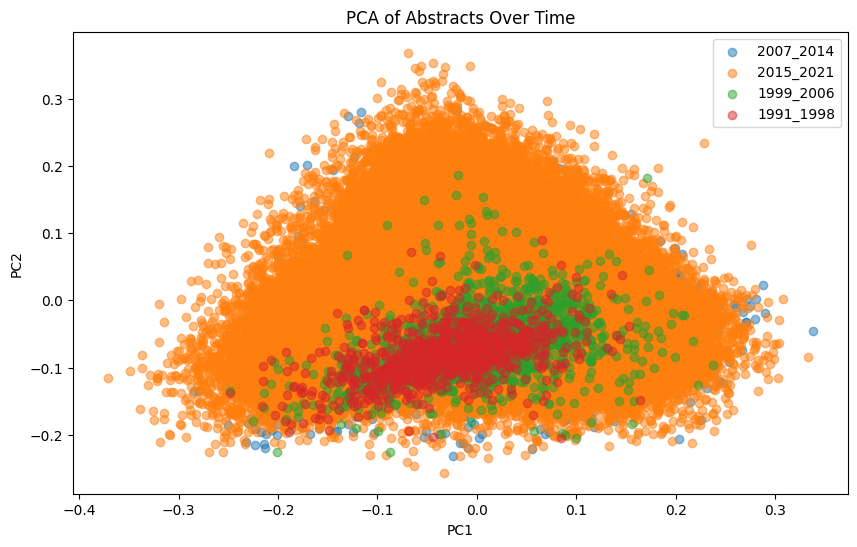

In [33]:
## High-dimensional text data --> Reduced to 2 dimensions using PCA 

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for period in df['period'].unique():
    subset = df[df['period'] == period]
    
    plt.scatter(
        subset['pca1'],
        subset['pca2'],
        label=period,
        alpha=0.5
    )

plt.legend()
plt.title("PCA of Abstracts Over Time")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

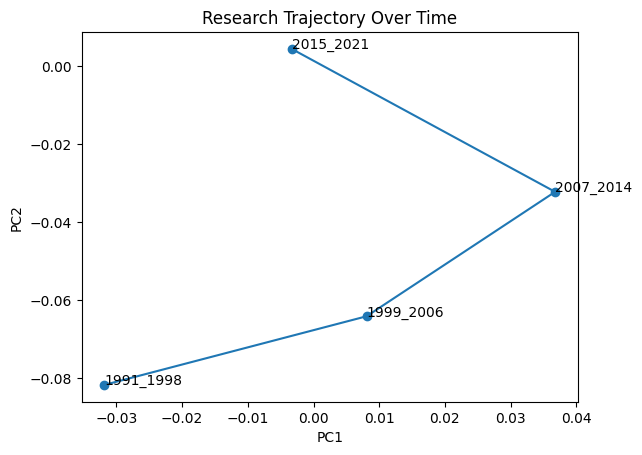

In [34]:
## average position of all abstracts in a time period 
plt.figure()
means = df.groupby('period')[['pca1', 'pca2']].mean()
plt.plot(means['pca1'], means['pca2'], marker='o')


for period in means.index:
    plt.text(
        means.loc[period, 'pca1'],
        means.loc[period, 'pca2'],
        period
    )

plt.title("Research Trajectory Over Time")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()